In [24]:
!pip install -q PyPortfolioOpt

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

In [4]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.443146,170.404495,41.931019,54.717323,76.912781,64.291069,540.298645,102.615845,341.583496,75.843285,...,154.084106,147.359787,392.184113,29.220688,453.210388,399.926666,230.069733,46.069382,45.858704,55.607391
2022-01-04,176.178391,167.522003,43.574478,55.142246,77.167374,67.079918,537.934143,104.482979,343.629333,79.329285,...,154.306808,147.875412,387.097321,30.639347,453.058624,383.196655,229.634155,47.903801,45.018566,57.699009
2022-01-05,171.492081,164.356995,42.839005,54.500549,77.485626,65.929512,524.291077,105.162735,340.098297,77.873299,...,154.832352,148.544846,375.205200,30.639347,444.358948,362.706665,224.653412,47.486057,45.627270,58.416649
2022-01-06,168.629303,163.253998,43.701599,56.286888,76.976448,68.404587,524.176697,106.057579,338.510437,79.470711,...,154.868027,147.296432,374.941620,31.367100,443.941437,354.899994,224.596588,48.702953,45.500458,59.790642
2022-01-07,168.795959,162.554001,44.654991,57.041302,76.776405,70.278343,511.191437,107.580559,338.435669,81.667137,...,155.063965,147.215057,370.879913,32.269882,442.186340,342.320007,223.573944,49.738224,45.934780,60.280708


# Setting Up Markowitz Portfolio Theory

First, let us set up Markowitz Portfolio Theory. Let $r$ be a matrix of T historical daily log returns of n stocks:

$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$

where:  
- $T$ is the number of days, so $T=752$  
- $n$ is number of stocks, so $n=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$

For our case, $r$ is 
Then $\hat{\mu}$ is a vector of means of annualized expected log return:

$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$

and $\hat{\Sigma}$ is the variance-covariance matrix of nnualized expected log return:

$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$

where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock.  

  Stock   Weight
0   MPC  0.14690
1  NVDA  0.14750
2   WMT  0.56538
3   XOM  0.14021

Expected annual return: 25.3%
Annual volatility: 18.2%
Sharpe Ratio: 1.28


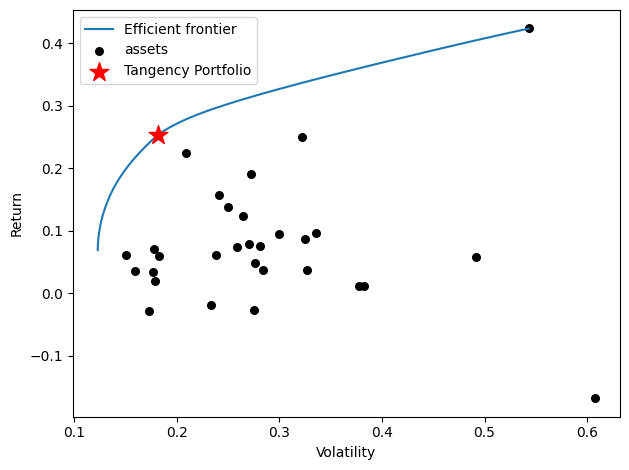

In [5]:
# mu and Sigma are annualized
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan.clean_weights().items() if weight > 0],
    columns=['Stock', 'Weight']
)
print(weights_df)
print()
exp_return, vol, sharpe = ef_tan.portfolio_performance(verbose=True, risk_free_rate=0.02)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)
plt.legend()
plt.show()

In [20]:
# Define date range
start = "2025-01-01"
end = "2025-03-01"

# Download historical data
close_test_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]

[*********************100%***********************]  30 of 30 completed


In [21]:
markowitz_allocator = {stock:weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
markowitz_allocator['XOM'] = 0.14022
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator()

# 6. Run backtests and add each stock to portfolio
for stock in markowitz_allocator.keys():
    alloc = markowitz_allocator[stock]

    bt = Backtest()
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")

# 7. Inspect results
portfolio.show_report()

PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
MPC      Markowitz Model      6.57%      0.08     -7.49%   100.00%      inf
NVDA     Markowitz Model     -9.74%     -0.04    -21.86%     0.00%     0.00
WMT      Markowitz Model      9.39%      0.14    -10.76%   100.00%      inf
XOM      Markowitz Model      4.54%      0.09     -4.85%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,258.72
Total Profit:          $258.72
Total Return:          2.59%
Sharpe Ratio:          0.05
Maximum Drawdown:      -6.65%
Volatility:            1.37%
